<a href="https://colab.research.google.com/github/magmatic654/-21_Dias_de_Python/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [42]:
import pandas as pd
path = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'

df = pd.read_json(path)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

## Conociendo el conjunto de datos

Diccionario de datos


- `customerID`: número de identificación único de cada cliente

- `Churn`: si el cliente dejó o no la empresa

- `gender`: género (masculino y femenino)

- `SeniorCitizen`: información sobre si un cliente tiene o no una edad igual o mayor a 65 años

- `Partner`: si el cliente tiene o no una pareja

- `Dependents`: si el cliente tiene o no dependientes

- `tenure`: meses de contrato del cliente

- `PhoneService`: suscripción al servicio telefónico

- `MultipleLines`: suscripción a más de una línea telefónica

- `InternetService`: suscripción a un proveedor de internet

- `OnlineSecurity`: suscripción adicional de seguridad en línea

- `OnlineBackup`: suscripción adicional de respaldo en línea

- `DeviceProtection`: suscripción adicional de protección del dispositivo

- `TechSupport`: suscripción adicional de soporte técnico, menor tiempo de espera

- `StreamingTV`: suscripción de televisión por cable

- `StreamingMovies`: suscripción de streaming de películas

- `Contract`: tipo de contrato

- `PaperlessBilling`: si el cliente prefiere recibir la factura en línea

- `PaymentMethod`: forma de pago

- `Charges.Monthly`: total de todos los servicios del cliente por mes

- `Charges.Total`: total gastado por el cliente



In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


Nuestras columnas no corresponden correctamente a lo solicitado, pues aun se encuentran sin normalizar los JSON de las columnas

## Comprobación de incoherencias en los datos

### Tratamiento

#### Columnas con JSON

In [44]:
records = df.to_dict(orient='records')
df = pd.json_normalize(records, )
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


Simplificamos el nombre de las columnas reemplazando su primer nivel antes del punto por un espacio en blanco

In [45]:
df.columns = df.columns.str.replace(r'^[^.]*\.', '', regex=True)
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#### Valores Nulos


In [46]:
df.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


#### No duplicados

In [47]:
print('Numero de Clientes:', df.shape[0])
print('Numero de Clientes unicos:', len(pd.unique(df['customerID'])))

Numero de Clientes: 7267
Numero de Clientes unicos: 7267


#### Valores Faltantes

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [49]:
for col in df.columns[1:19]:
  print(f'\n{col}: {pd.unique(df[col])}')


Churn: ['No' 'Yes' '']

gender: ['Female' 'Male']

SeniorCitizen: [0 1]

Partner: ['Yes' 'No']

Dependents: ['Yes' 'No']

tenure: [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]

PhoneService: ['Yes' 'No']

MultipleLines: ['No' 'Yes' 'No phone service']

InternetService: ['DSL' 'Fiber optic' 'No']

OnlineSecurity: ['No' 'Yes' 'No internet service']

OnlineBackup: ['Yes' 'No' 'No internet service']

DeviceProtection: ['No' 'Yes' 'No internet service']

TechSupport: ['Yes' 'No' 'No internet service']

StreamingTV: ['Yes' 'No' 'No internet service']

StreamingMovies: ['No' 'Yes' 'No internet service']

Contract: ['One year' 'Month-to-month' 'Two year']

PaperlessBilling: ['Yes' 'No']

PaymentMethod: ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']


Se repiten valores para escribir "No" en distintas columnas, pudiendo ser alguna de las siguientes:
- `"No phone service"`
- `"No internet service"`
- `""`

Sera mejor pasarlos a booleanos para simplificar, por lo que primero normalizamos "Yes" y "No"

Tambien se detecta que hay filas sin estar etiquetadas en la columna `Churn`: `""`

In [50]:
import numpy as np

# 1. Convertimos espacios vacíos o puros espacios en blanco a NaN
df['Churn'] = df['Churn'].replace(r'^\s*$', np.nan, regex=True)

# 2. Ahora sí, eliminamos
df = df.dropna(subset=['Churn'])
df['Churn'].unique()

array(['No', 'Yes'], dtype=object)

In [51]:
# Diccionario de Regex
# (?i)  -> Ignora mayúsculas/minúsculas (case-insensitive)
# ^     -> Indica que debe empezar con esa palabra
# .* -> Coincide con cualquier carácter que venga después
mapeo_regex = {
    r'(?i)^Yes.*': 0,
    r'(?i)^No.*': 1
}

# Estandarizar todas las columnas de yes y
for col in df.columns:
  df[col] = df[col].replace(mapeo_regex, regex=True)


/tmp/ipykernel_314/2649228859.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace(mapeo_regex, regex=True)


#### Columna Cuenta Diaria

In [52]:
df['Cuentas_Diarias'] = round(df['Charges.Monthly'] / 30, 2)
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,1,Female,0,0,0,9,0,1,DSL,...,1,0,0,1,One year,0,Mailed check,65.6,593.3,2.19
1,0003-MKNFE,1,Male,0,1,1,9,0,0,DSL,...,1,1,1,0,Month-to-month,1,Mailed check,59.9,542.4,2.00
2,0004-TLHLJ,0,Male,0,1,1,4,0,1,Fiber optic,...,0,1,1,1,Month-to-month,0,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,0,Male,1,0,1,13,0,1,Fiber optic,...,0,1,0,0,Month-to-month,0,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,0,Female,1,0,1,3,0,1,Fiber optic,...,1,0,0,1,Month-to-month,0,Mailed check,83.9,267.4,2.80


#📊 Carga y análisis

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import math

In [54]:
df.describe()

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Charges.Monthly,Cuentas_Diarias
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.734630,0.162147,0.516967,0.700412,32.371149,0.096834,0.578163,0.713332,0.655119,0.656112,0.709783,0.615647,0.612097,0.407781,64.761692,2.158675
std,0.441561,0.368612,0.499748,0.458110,24.559481,0.295752,0.493888,0.452237,0.475363,0.475038,0.453895,0.486477,0.487307,0.491457,30.090047,1.003088
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.610000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.500000,1.180000
50%,1.000000,0.000000,1.000000,1.000000,29.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,70.350000,2.340000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.850000,2.990000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,3.960000


Distribucion categorica

Ranking de Impacto en Churn:
             columna    impacto
13          Contract  39.877819
6    InternetService  34.487785
15     PaymentMethod  30.042311
1      SeniorCitizen  18.075092
14  PaperlessBilling  17.235009
7     OnlineSecurity  16.718424
10       TechSupport  16.019897
3         Dependents  15.828904
2            Partner  13.293076
8       OnlineBackup   7.640591
9   DeviceProtection   6.149743
11       StreamingTV   5.739008
12   StreamingMovies   5.561941


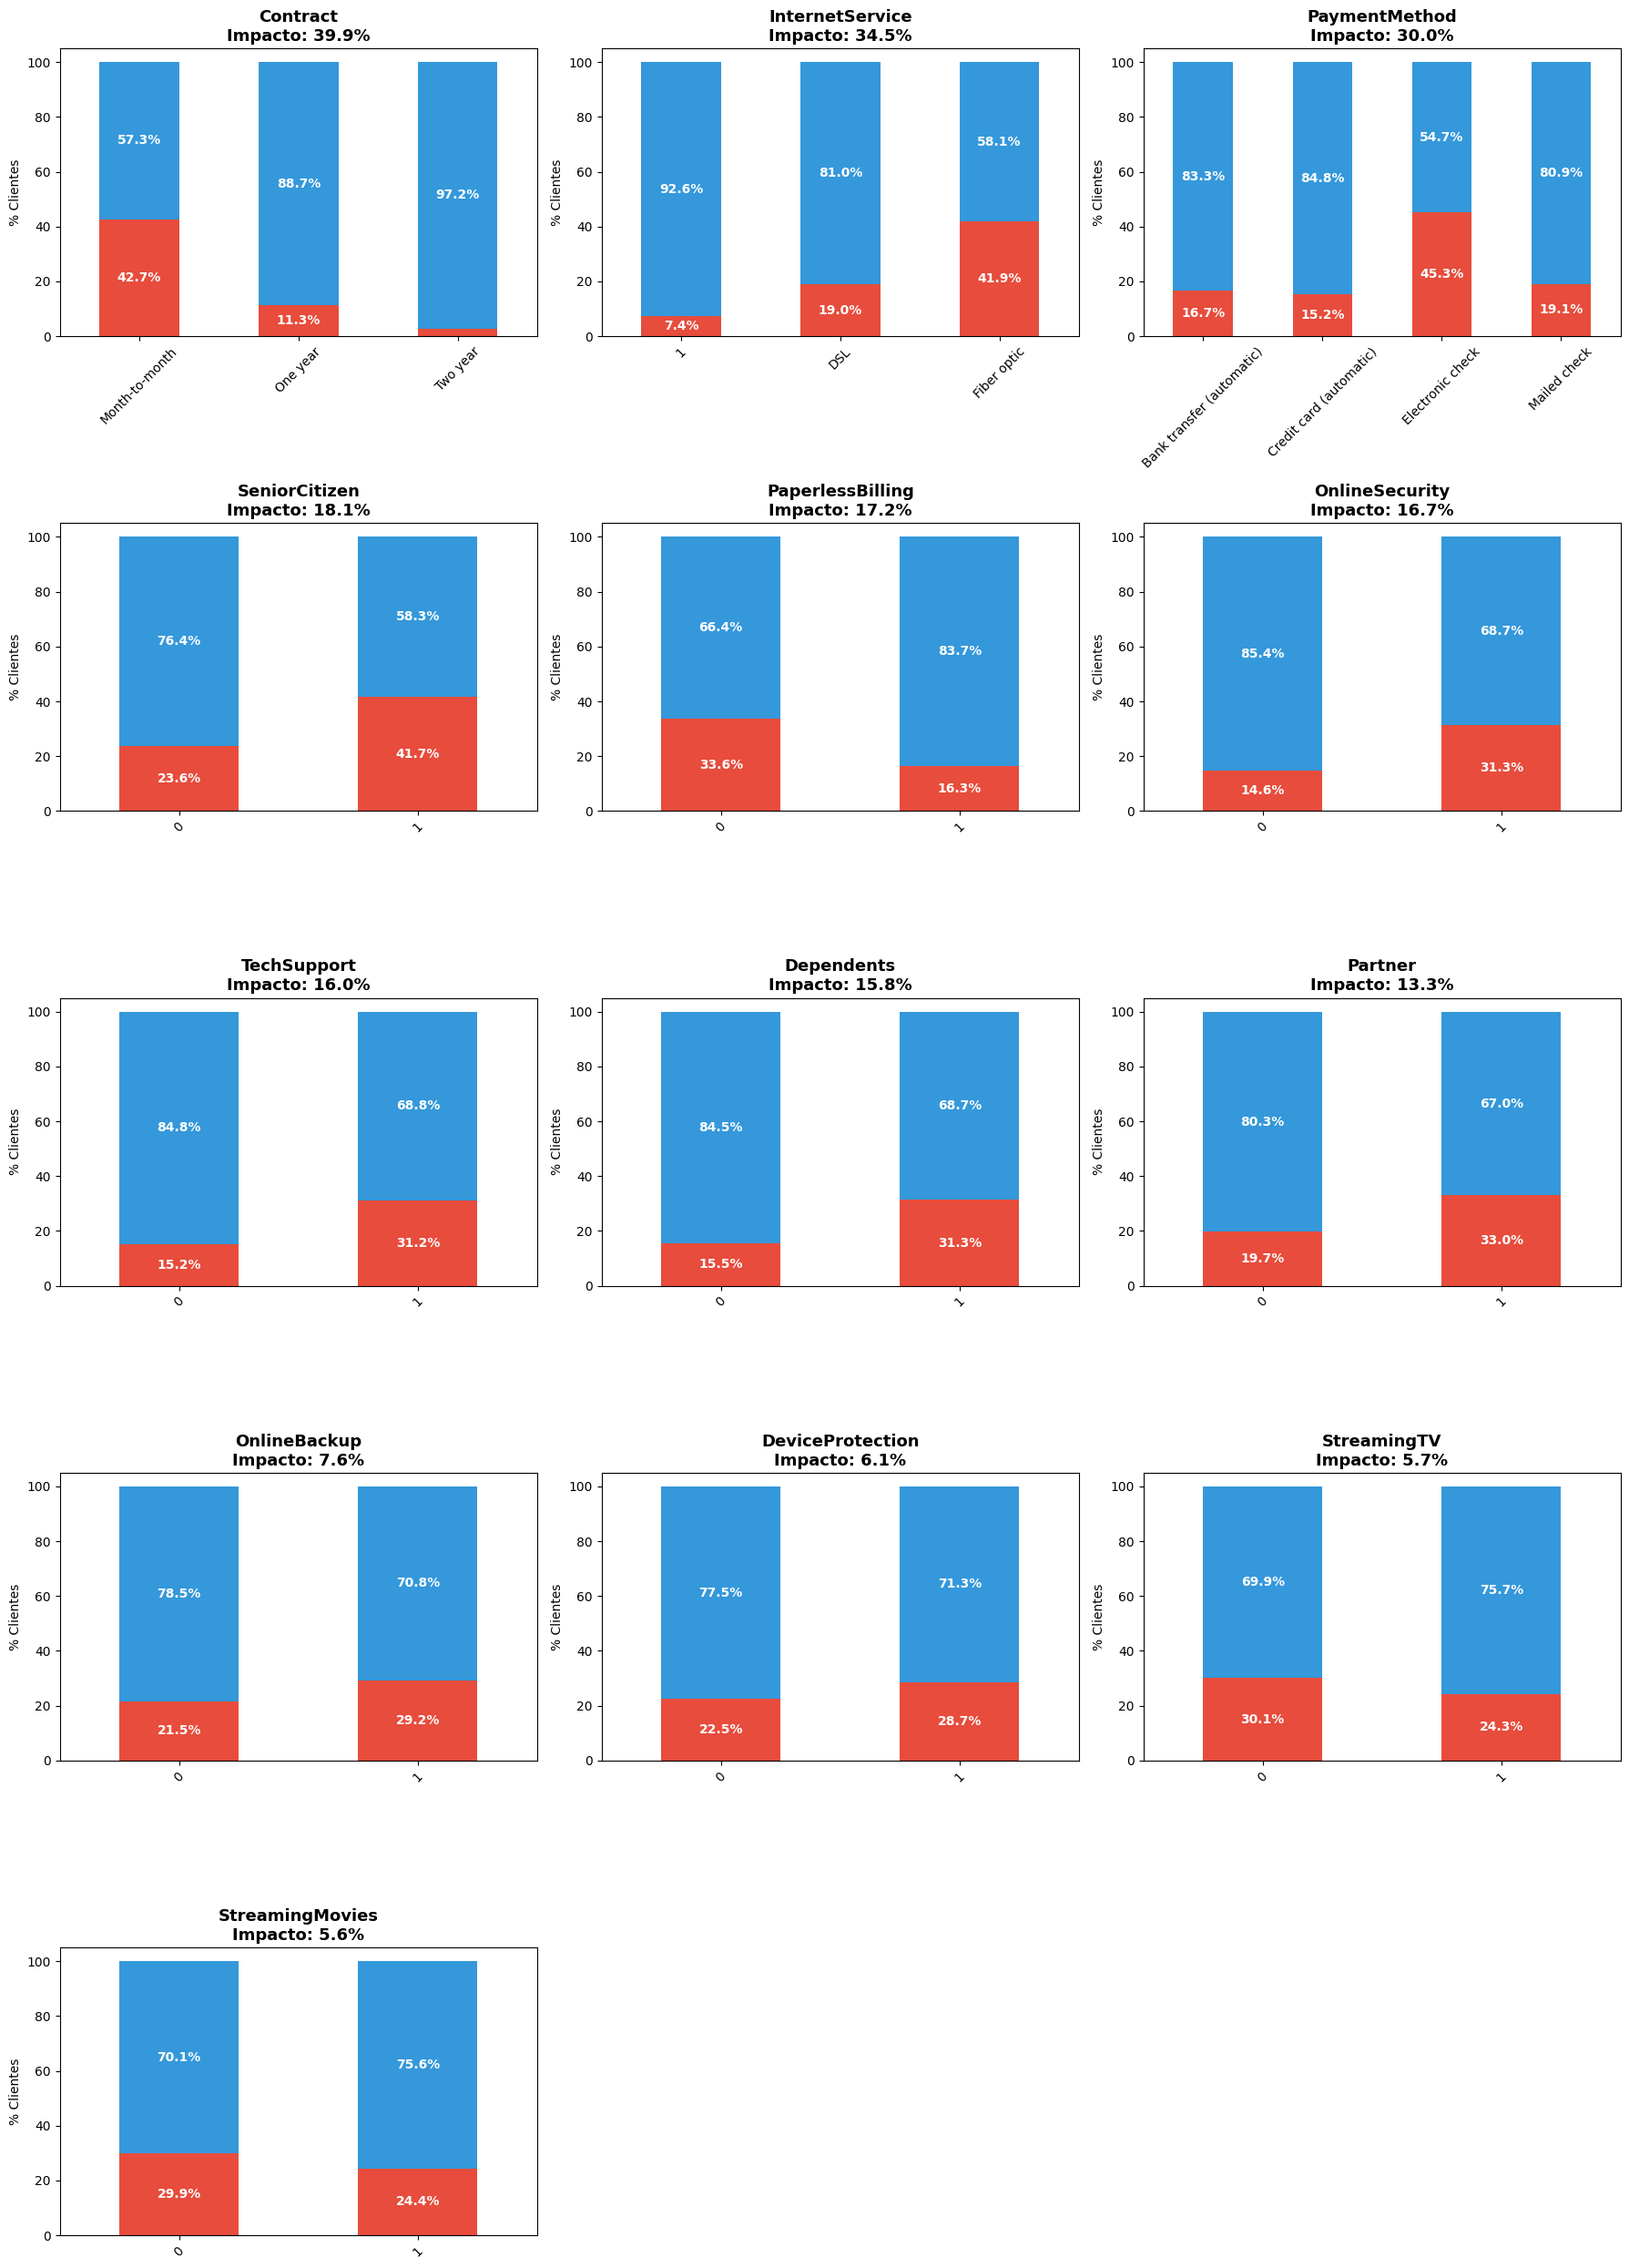

In [63]:
# 1. Definir columnas y excluir 'tenure'
cols_to_check = [col for col in df.columns[2:19] if col not in ['tenure', 'ternure']]
impactos = []

# 2. Calcular el impacto para cada columna
for col in cols_to_check:
    # Generamos la tabla de contingencia normalizada
    ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100

    # Verificamos que existan datos de Churn (True)
    if 1 in ct.columns:
        # Impacto = Diferencia entre el máximo y mínimo porcentaje de Churn en las categorías
        diff = ct[1].max() - ct[1].min()
        impactos.append({'columna': col, 'impacto': diff})

# 3. Guardar y Organizar de mayor a menor
df_impactos = pd.DataFrame(impactos).sort_values(by='impacto', ascending=False)

# Filtramos solo las que tienen impacto > 5%
df_filtrado = df_impactos[df_impactos['impacto'] > 5]

print("Ranking de Impacto en Churn:")
print(df_filtrado)

# 4. Configurar la cuadrícula con las columnas ordenadas
cols_ordenadas = df_filtrado['columna'].tolist()
n_cols = 3
n_rows = math.ceil(len(cols_ordenadas) / n_cols)

if len(cols_ordenadas) > 0:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
    axes = axes.flatten()

    for i, col in enumerate(cols_ordenadas):
        # Obtener el valor del impacto para el título
        val_impacto = df_filtrado[df_filtrado['columna'] == col]['impacto'].values[0]

        reporte_pct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100

        # Graficar (Ordenando también las barras para que sean consistentes)
        reporte_pct.plot(kind='bar', stacked=True, ax=axes[i], color=['#e74c3c', '#3498db'], legend=False)

        axes[i].set_title(f'{col}\nImpacto: {val_impacto:.1f}%', fontsize=13, fontweight='bold')
        axes[i].set_ylabel('% Clientes')
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=45)

        # Añadir etiquetas
        for p in axes[i].patches:
            h = p.get_height()
            if h > 5:
                axes[i].annotate(f'{h:.1f}%', (p.get_x() + p.get_width()/2., p.get_y() + h/2.),
                                 ha='center', va='center', color='white', fontsize=10, fontweight='bold')

    # Ocultar cuadros vacíos
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Ninguna columna superó el umbral del 5% de impacto.")

Conteo de evasion por variables numericas

In [56]:
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,1,Female,0,0,0,9,0,1,DSL,...,1,0,0,1,One year,0,Mailed check,65.6,593.3,2.19
1,0003-MKNFE,1,Male,0,1,1,9,0,0,DSL,...,1,1,1,0,Month-to-month,1,Mailed check,59.9,542.4,2.00
2,0004-TLHLJ,0,Male,0,1,1,4,0,1,Fiber optic,...,0,1,1,1,Month-to-month,0,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,0,Male,1,0,1,13,0,1,Fiber optic,...,0,1,0,0,Month-to-month,0,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,0,Female,1,0,1,3,0,1,Fiber optic,...,1,0,0,1,Month-to-month,0,Mailed check,83.9,267.4,2.80


#📄Informe final

In [57]:
print("Unique values in 'Charges.Total':", df['Charges.Total'].unique())
print("Number of non-numeric values in 'Charges.Total':", pd.to_numeric(df['Charges.Total'], errors='coerce').isnull().sum())

Unique values in 'Charges.Total': ['593.3' '542.4' '280.85' ... '742.9' '4627.65' '3707.6']
Number of non-numeric values in 'Charges.Total': 11


In [58]:
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')
df['Charges.Total'] = df['Charges.Total'].fillna(df['Charges.Total'].median())
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,1,Female,0,0,0,9,0,1,DSL,...,1,0,0,1,One year,0,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,1,Male,0,1,1,9,0,0,DSL,...,1,1,1,0,Month-to-month,1,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,0,Male,0,1,1,4,0,1,Fiber optic,...,0,1,1,1,Month-to-month,0,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,0,Male,1,0,1,13,0,1,Fiber optic,...,0,1,0,0,Month-to-month,0,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,0,Female,1,0,1,3,0,1,Fiber optic,...,1,0,0,1,Month-to-month,0,Mailed check,83.9,267.40,2.80


## Bin 'Charges.Total' y Conversión

Crear 5 grupos (bins) para las columnas 'Charges.Total' y 'tenure'.


In [59]:
df['Charges.Total_Bins'] = pd.qcut(df['Charges.Total'], q=5, labels=False)
df['tenure_Bins'] = pd.qcut(df['tenure'], q=5, labels=False)
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias,Charges.Total_Bins,tenure_Bins
0,0002-ORFBO,1,Female,0,0,0,9,0,1,DSL,...,0,1,One year,0,Mailed check,65.6,593.30,2.19,1,1
1,0003-MKNFE,1,Male,0,1,1,9,0,0,DSL,...,1,0,Month-to-month,1,Mailed check,59.9,542.40,2.00,1,1
2,0004-TLHLJ,0,Male,0,1,1,4,0,1,Fiber optic,...,1,1,Month-to-month,0,Electronic check,73.9,280.85,2.46,1,0
3,0011-IGKFF,0,Male,1,0,1,13,0,1,Fiber optic,...,0,0,Month-to-month,0,Electronic check,98.0,1237.85,3.27,2,1
4,0013-EXCHZ,0,Female,1,0,1,3,0,1,Fiber optic,...,0,1,Month-to-month,0,Mailed check,83.9,267.40,2.80,1,0


In [60]:
churn_by_charges_bins = pd.crosstab(df['Charges.Total_Bins'], df['Churn'], normalize='index') * 100
churn_by_tenure_bins = pd.crosstab(df['tenure_Bins'], df['Churn'], normalize='index') * 100

print("Churn Rate by Charges.Total Bins:")
print(churn_by_charges_bins)

print("\nChurn Rate by Tenure Bins:")
print(churn_by_tenure_bins)

Churn Rate by Charges.Total Bins:
Churn                       0          1
Charges.Total_Bins                      
0                   45.990064  54.009936
1                   28.906250  71.093750
2                   20.652945  79.347055
3                   23.011364  76.988636
4                   14.123492  85.876508

Churn Rate by Tenure Bins:
Churn                0          1
tenure_Bins                      
0            52.937205  47.062795
1            33.428776  66.571224
2            22.372159  77.627841
3            15.555556  84.444444
4             6.609808  93.390192


## Análisis y Visualización de la Tasa de Abandono por Cargos Totales

### Subtask:
Visualizar la tasa de abandono por 'Charges.Total' binned.


**Reasoning**:
To visualize the churn rate by 'Charges.Total_Bins', I will create a stacked bar chart using the 'churn_by_charges_bins' DataFrame, applying the specified colors, title, and y-axis label.



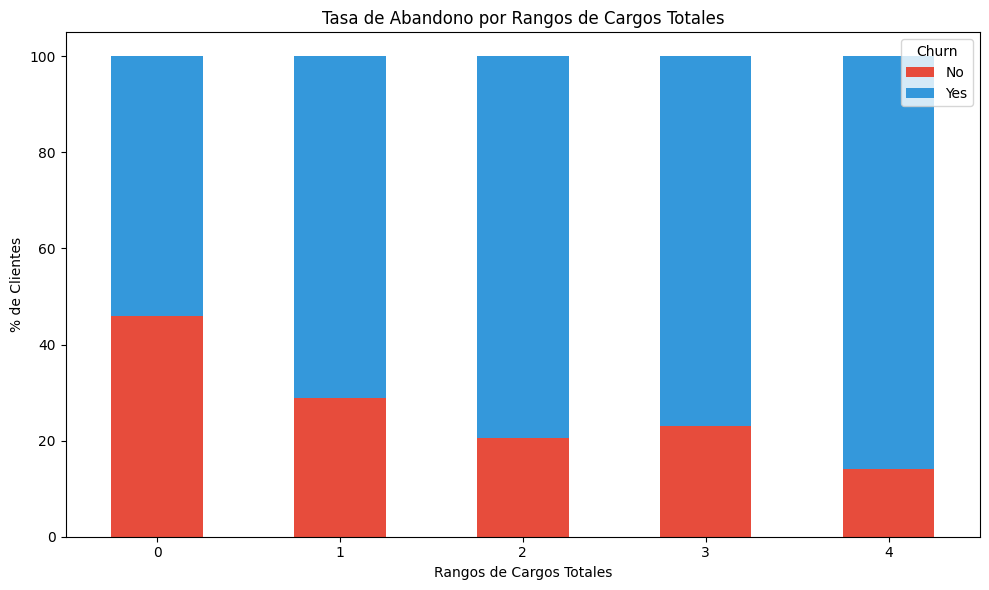

In [64]:
churn_by_charges_bins.plot(kind='bar', stacked=True, color=['#e74c3c', '#3498db'], figsize=(10, 6))
plt.title('Tasa de Abandono por Rangos de Cargos Totales')
plt.ylabel('% de Clientes')
plt.xlabel('Rangos de Cargos Totales')
plt.xticks(rotation=0)
plt.legend(title='Churn', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

**Reasoning**:
To visualize the churn rate by 'tenure_Bins', I will create a stacked bar chart using the 'churn_by_tenure_bins' DataFrame, applying similar colors, title, and y-axis label for consistency.



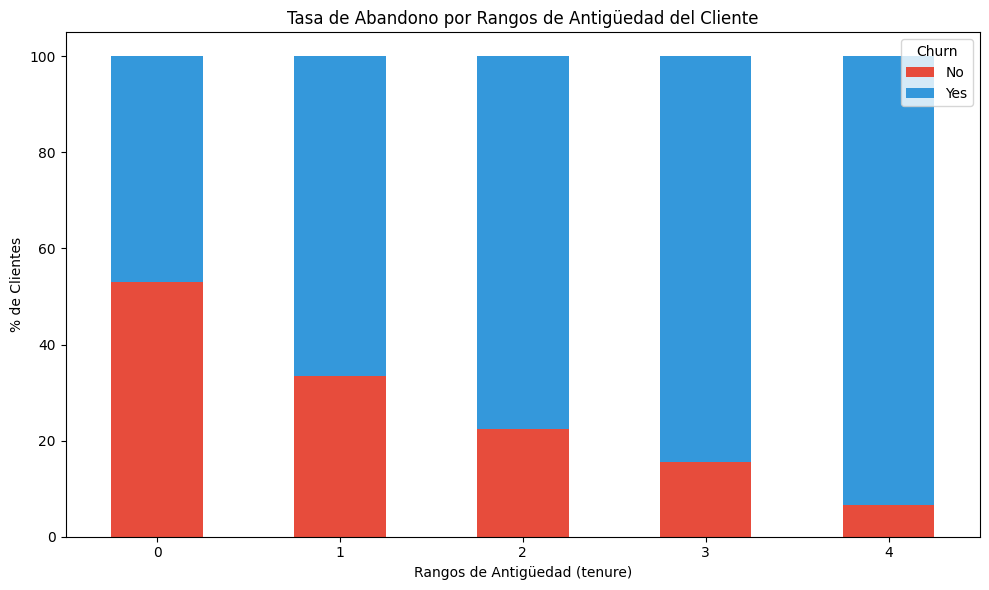

In [65]:
churn_by_tenure_bins.plot(kind='bar', stacked=True, color=['#e74c3c', '#3498db'], figsize=(10, 6))
plt.title('Tasa de Abandono por Rangos de Antigüedad del Cliente')
plt.ylabel('% de Clientes')
plt.xlabel('Rangos de Antigüedad (tenure)')
plt.xticks(rotation=0)
plt.legend(title='Churn', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()